# Student Performance Prediction in Bangladesh
This notebook demonstrates a complete machine learning pipeline to predict HSC results based on student demographics, family background, and previous academic performance (SSC results).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('bangladesh_student_performance_updated.csv')
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
909,29/04/2018,M,19.0,Rural,GT3,Together,2,2,Teacher,Business,Yes,No,45040.0,2,4.32,3.43
1566,29/04/2018,F,19.0,Rural,GT3,Together,2,1,At_home,Health,No,No,49716.0,3,3.57,2.79
660,29/04/2018,M,18.0,Urban,LE3,Together,1,2,At_home,Services,No,No,107953.0,5,4.22,3.48
1100,29/04/2018,M,17.0,Rural,GT3,Together,1,3,Teacher,Teacher,Yes,No,33948.0,2,3.50,2.77
1821,29/04/2018,M,17.0,Rural,GT3,Together,2,0,Services,Farmer,No,Yes,50448.0,3,4.13,3.46
1398,29/04/2018,F,NaN,Rural,GT3,Together,1,2,Health,Services,No,No,52804.0,2,3.08,2.52
650,29/04/2018,M,19.0,Rural,GT3,Together,3,3,Other,Business,No,No,43159.0,4,2.51,2.12
2012,29/04/2018,F,18.0,Urban,LE3,Together,0,2,NaN,Business,No,No,72784.0,2,4.57,4.20
1848,29/04/2018,F,18.0,NaN,LE3,Together,0,2,Other,Health,No,No,26431.0,1,4.36,3.87
353,29/04/2018,M,18.0,Urban,GT3,Together,4,0,Teacher,Business,Yes,No,95834.0,4,2.78,2.00


In [3]:
df.shape

(2018, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [5]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [6]:
df['time_friends'].value_counts()
df['M_Edu'].unique()
df['time_friends'].unique()

array([4, 5, 3, 2, 1])

In [7]:
df.isnull().sum()

date             0
gender           0
age             35
address         35
famsize          0
Pstatus          0
M_Edu            0
F_Edu            0
M_Job           35
F_Job            0
relationship     0
smoker           0
tuition_fee     35
time_friends     0
ssc_result       0
hsc_result       0
dtype: int64

## 2. Exploratory Data Analysis (EDA)
Visualizing the data helps us identify patterns, correlations between features, and potential outliers. We look at the distribution of numerical features and the relationship between our target variable (`hsc_result`) and other predictors.

In [8]:
print(f'Duplicate :  {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Duplicate after removal: {df.duplicated().sum()}')

Duplicate :  0
Duplicate after removal: 0


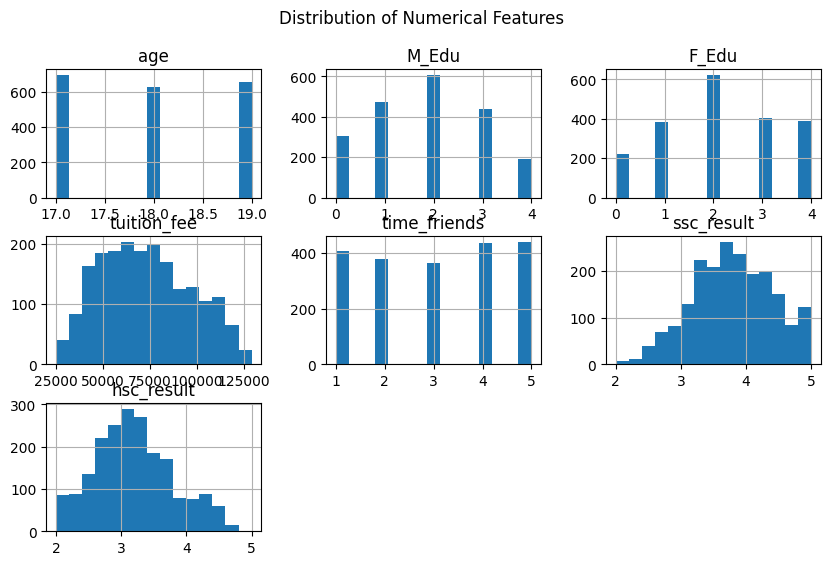

In [9]:
df.hist(  figsize=(10,6), bins=15) # figsize(width, height) inch
plt.suptitle("Distribution of Numerical Features")
plt.show()


In [10]:
numerical_coloumns = df[['age' , 'tuition_fee' , 'ssc_result' , 'hsc_result']]

numerical_coloumns.sample(4)

numerical_coloumns.corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


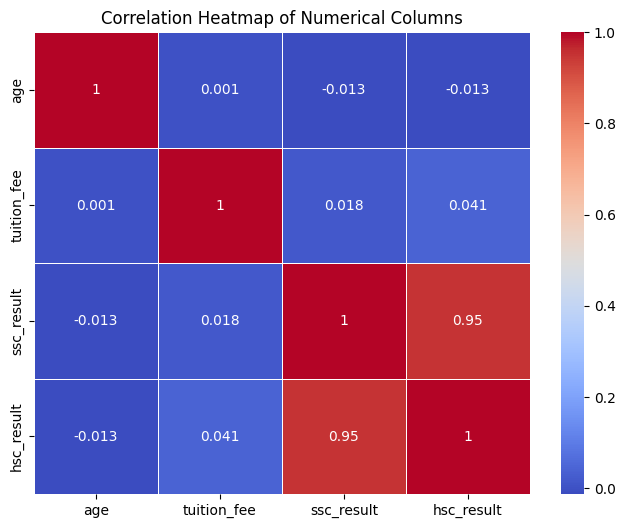

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(numerical_coloumns.corr() , annot= True , cmap='coolwarm' , linewidths=0.5) # annot show s number 

plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

<Axes: xlabel='ssc_result', ylabel='hsc_result'>

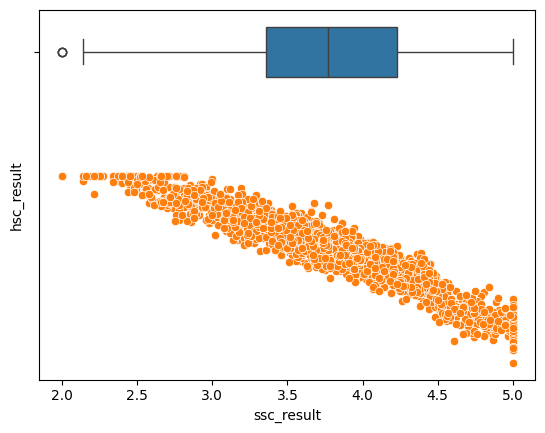

In [12]:
sns.boxplot(data= df, x="ssc_result") # shows outlines 
sns.scatterplot(data=df, x='ssc_result', y='hsc_result')

Preprocessing is a critical step where we handle missing values, encode categorical variables (nominal and ordinal), and scale numerical features to prepare them for the machine learning models.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline

#### Missing numbers   ->    SimpleImputer(strategy='mean')

#### Missing categories   ->    SimpleImputer(strategy='most_frequent')

#### Different scales (age vs salary)    -> StandardScaler()

#### Text categories (male/female)   ->   OneHotEncoder()

#### Ordered categories (low/mid/high)    ->     OrdinalEncoder() ####

In [ ]:
numerical_cat =['age' , 'tuition_fee' , 'ssc_result' ] 

nominal_cat = ['gender' ,'address' , 'famsize' , 'Pstatus' , 'relationship' , 'smoker' , 'F_Job' , 'M_Job']

ordinal_cat = ['M_Edu' , 'F_Edu' , 'time_friends' , 'relationship'] 


In [15]:
# Pipeline for numerical features:
# 1. Fill missing values using the mean of the column
# 2. Standardize features scaling

numerical_transformer = Pipeline(steps=
                                 [('imputer', SimpleImputer(strategy='mean')) ,
                                  
                                  ('Scaler' , StandardScaler())
                                  
                                  ])

In [16]:
# Pipeline for categorical features:
# 1. Fill missing values with the most frequent category
# 2. Convert categories  (one-hot encoding)

nominal_transformer = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy ='most_frequent')) ,
    ('encoder', OneHotEncoder(sparse_output=False , handle_unknown='ignore'))
]
    
)


In [17]:
#Combine all transformations into a single preprocessor

preprocessor = ColumnTransformer(
    
    transformers=[
        ('numerical' , numerical_transformer ,numerical_cat)  ,
        ('nominal' , nominal_transformer , nominal_cat)
    ] ,
    remainder='passthrough' # Pass through any columns not specified in the transformers rather than numerical_cat and nominal_cat only
)

In [18]:
# Split features (X) and target (y) , 80-20 train-test split randomly 

X= df.drop(['date' , 'hsc_result'], axis=1)  # Features
y= df['hsc_result']  # Target

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2 , random_state=42)


## 3. Model Training
We evaluate two different linear regression models to see which one performs better on this specific dataset:
1. **Linear Regression**: A standard approach for regression tasks.
2. **SGD Regressor**: Uses Stochastic Gradient Descent, which is efficient for larger datasets.

In [19]:
from sklearn.linear_model import LinearRegression,SGDRegressor

#### the steps inside the lr_pipe are executed in order:

1) #### preprocessor.fit_transform(X_train) is called internally to handle imputation, scaling, and one-hot encoding.
2) #### The transformed X_train data is then fed to the LinearRegression() model for its fit() method.

In [20]:
# This combines our preprocessing steps with the Linear Regression algorithm

lr_pipe= Pipeline(steps=[
    ('preprocessor' , preprocessor) ,  # processing the train data using the preprocessor pipeline we just made
    ('model' , LinearRegression())
])

# Train (fit) the Linear Regression model using X_train and y_train
lr_pipe.fit(X_train , y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
print("Missing values in X_train before preprocessing:")
print(X_train.isnull().sum())


# transforms X_train with (imputing missing values, scaling numerical features, 
# and one-hot encoding nominal categorical features).

X_train_transformed = preprocessor.fit_transform(X_train) #it does not effect X_train but returns new array

# Get feature names after one-hot encoding for nominal categories
nominal_feature_names = preprocessor.named_transformers_['nominal'].named_steps['encoder'].get_feature_names_out(nominal_cat)

passthrough_cols = ['M_Edu', 'F_Edu', 'time_friends']

# Combine numerical, nominal, and passthrough feature names
all_feature_names = numerical_cat + list(nominal_feature_names) + passthrough_cols

# Create a DataFrame from the transformed data for easy inspection
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=all_feature_names)

print("Missing values in X_train after preprocessing:")
print(X_train_transformed_df.isnull().sum())
display(X_train_transformed_df)

Missing values in X_train before preprocessing:
gender           0
age             26
address         26
famsize          0
Pstatus          0
M_Edu            0
F_Edu            0
M_Job           26
F_Job            0
relationship     0
smoker           0
tuition_fee     28
time_friends     0
ssc_result       0
dtype: int64
Missing values in X_train after preprocessing:
age                 0
tuition_fee         0
ssc_result          0
gender_F            0
gender_M            0
address_Rural       0
address_Urban       0
famsize_GT3         0
famsize_LE3         0
Pstatus_Apart       0
Pstatus_Together    0
relationship_No     0
relationship_Yes    0
smoker_No           0
smoker_Yes          0
F_Job_Business      0
F_Job_Farmer        0
F_Job_Health        0
F_Job_Services      0
F_Job_Teacher       0
M_Job_At_home       0
M_Job_Health        0
M_Job_Other         0
M_Job_Services      0
M_Job_Teacher       0
M_Edu               0
F_Edu               0
time_friends        0
dtype: int

,age,tuition_fee,ssc_result,gender_F,gender_M,address_Rural,address_Urban,famsize_GT3,famsize_LE3,Pstatus_Apart,...,F_Job_Services,F_Job_Teacher,M_Job_At_home,M_Job_Health,M_Job_Other,M_Job_Services,M_Job_Teacher,M_Edu,F_Edu,time_friends
0,1.246761,-0.980973,1.859366,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,3.0
1,-1.194493,0.631699,-1.778715,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0
2,-1.194493,1.806316,-0.063849,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,3.0,4.0
3,0.026134,0.269375,-0.143983,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,3.0
4,0.026134,0.307449,0.256687,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1609,0.026134,-0.952438,0.064365,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0
1610,1.246761,1.584081,-0.785054,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,3.0,2.0
1611,1.246761,-0.886913,1.939499,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0
1612,0.026134,-1.126269,1.009946,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,4.0,1.0


In [22]:
X_test 

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
1556,F,17.0,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743.0,1,3.88
526,M,19.0,Rural,GT3,Together,4,3,At_home,Business,No,No,58678.0,5,4.36
393,F,18.0,Urban,GT3,Together,2,1,Services,Services,No,No,115832.0,3,4.47
1789,M,17.0,Urban,GT3,Together,2,3,Health,Teacher,No,Yes,112781.0,1,4.43
433,M,19.0,Rural,LE3,Together,1,0,Teacher,Farmer,No,Yes,52481.0,4,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,M,17.0,Rural,GT3,Apart,1,4,Health,Teacher,No,No,60345.0,4,3.47
693,M,19.0,Urban,GT3,Together,1,2,Health,Business,No,No,85346.0,4,2.96
1494,F,18.0,Rural,LE3,Together,1,4,Teacher,Teacher,No,No,30638.0,1,3.76
921,M,NaN,Urban,GT3,Together,0,1,Teacher,Teacher,No,No,76804.0,2,4.18


In [24]:
y_pred= lr_pipe.predict(X_test)

#### SGD Regression ####

In [26]:
SGD_pipe= Pipeline(steps=[
    ('preprocessor' , preprocessor)  , # preprocessor is defin ed above
    ('model' , SGDRegressor())
])

SGD_pipe.fit(X_train , y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
y_pred2=SGD_pipe.predict(X_test)

## Accuracy Evaluation

MSE = mean_squared_error

RMSE =root mean squared error

R2  measures the proportion of variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1, where a higher value indicates a better fit.

MAE measures average (mean) absolute error is



#### For linear Regression

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error

print(f"MSE: {round(mean_squared_error(y_test, y_pred), 4)}")
print(f"R2: {round(r2_score(y_test, y_pred), 4)}")
print(f"RMSE: {round(root_mean_squared_error(y_test, y_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred), 4)}") #

MSE: 0.0203
R2: 0.9459
RMSE: 0.1425
MAE: 0.1114


####  for SGD regression

In [ ]:
print(f"MSE: {round(mean_squared_error(y_test, y_pred2), 4)}")
print(f"R2: {round(r2_score(y_test, y_pred2), 4)}")
print(f"RMSE: {round(root_mean_squared_error(y_test, y_pred2), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred2), 4)}") 

MSE: 0.0205
R2: 0.9453
RMSE: 0.1432
MAE: 0.1127


In [ ]:
#